In [ ]:
!pip install -U diffusers

## Local Inference on GPU
Model page: https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [1]:
pip install -U diffusers transformers accelerate

In [3]:
import torch
from diffusers import DiffusionPipeline

# switch to "mps" for apple devices
pipe = DiffusionPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5", dtype=torch.bfloat16, device_map="cuda")

prompt = "Astronaut in a jungle, cold color palette, muted colors, detailed, 8k"
image = pipe(prompt).images[0]

Keyword arguments {'dtype': torch.bfloat16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [4]:
image.save("test.png")

In [5]:
guidance_scales = [4, 7.5, 12]
steps = [20, 40, 60]

In [6]:
for g in guidance_scales:
    for s in steps:
        image = pipe(prompt, guidance_scale=g, num_inference_steps=s).images[0]
        image.save(f"test_g{g}_s{s}.png")

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

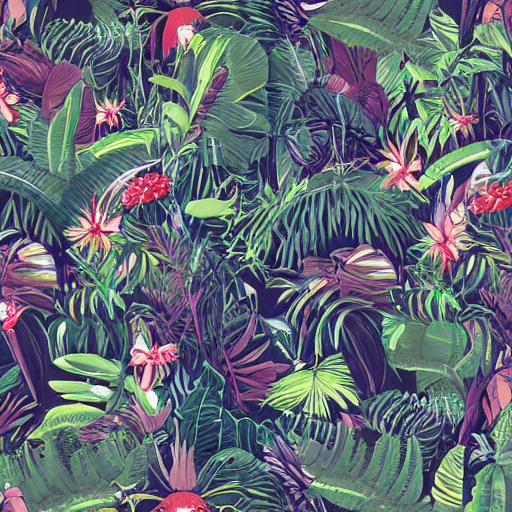

In [15]:
from PIL import Image
image = Image.open("test_g4_s20.png")
image

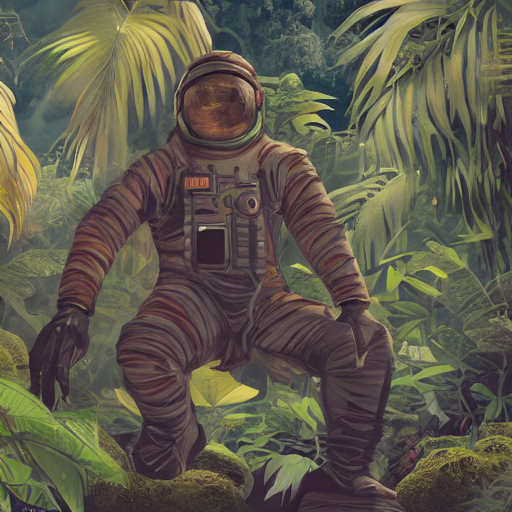

In [16]:
image = Image.open("test_g4_s40.png")
image

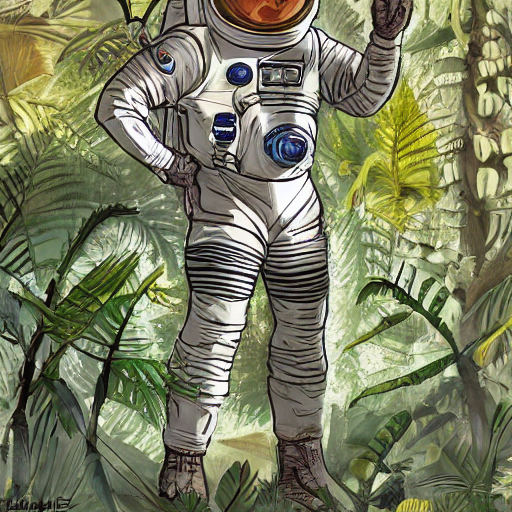

In [17]:
image = Image.open("test_g4_s60.png")
image